# 04. MODEL tag EDA — почему нужен `B-MODEL` / `I-MODEL`

Проблема: после бренда часто идёт хвост (`g pro x se`, `v15`, `galaxy s24`), который при текущей silver-разметке остаётся **`O`**.  
CRF не выучит MODEL, если в train-тегах его нет.

Этот ноутбук:
1. показывает масштаб проблемы графиками;
2. объясняет **майнинг** `model_phrases.txt` (парсинг `sku_name`, не ML);
3. подбирает **пороги** попадания фразы в словарь;
4. сохраняет `artifacts/model_phrases.txt` и проверяет `WeakLabeler` с тегом MODEL.


## 0. Setup


In [1]:
%matplotlib inline
import sys
from pathlib import Path
from collections import Counter, defaultdict

ROOT = Path.cwd().resolve()
if ROOT.name in {"complex_eda", "notebooks"}:
    ROOT = ROOT.parents[1] if ROOT.name == "complex_eda" else ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data_utils import (
    apply_plot_style, ensure_dirs, load_query_clicks, ARTIFACTS_DIR, FIGURES_DIR,
    MVIDEO_RED, DARK_SLATE, MUTED, save_stats,
)
from src.ner.labeling import WeakLabeler, bio_to_entities, entities_to_structured
from src.preprocessing import (
    QueryPreprocessor, build_model_lexicon_from_titles, save_phrase_list, load_phrase_list,
)
from src.preprocessing.pipeline import MODEL_SEEDS, basic_clean

ensure_dirs()
apply_plot_style()
FIG = FIGURES_DIR / "complex_eda" / "model_tag"
FIG.mkdir(parents=True, exist_ok=True)
ART = ARTIFACTS_DIR

def save_local(fig, name):
    p = FIG / name
    fig.savefig(p, dpi=170, bbox_inches="tight", facecolor="white")
    print("saved", p)
    return p

SAMPLE_N = 180_000
print("ROOT:", ROOT)


ROOT: D:\Projects-26-06-2026\mvideo-ner-search


In [2]:
clicks = load_query_clicks(n=SAMPLE_N, seed=42, random=True)
# labeler БЕЗ model-словаря — «как было»
labeler_base = WeakLabeler.from_files(ART / "brands.txt", ART / "categories.txt")
print(f"clicks={len(clicks):,}  brands_dict={len(labeler_base.brands):,}")


clicks=180,000  brands_dict=1,609


## 1. Проблема: нет тега MODEL → хвост после бренда = `O`

Если в запросе есть бренд, а дальше латинский хвост без ATTR-regex — токены остаются `O`.  
Для поиска это потеря сигнала линейки; для обучения NER — **отсутствие класса**, который мы хотим предсказывать.


In [3]:
def brand_latin_o_tail(tags):
    # Хвост после последнего BRAND: все O, >=1 токен, преимущественно латиница/цифры
    brand_idx = [i for i, (_, t) in enumerate(tags) if t.endswith("BRAND")]
    if not brand_idx:
        return None
    last = max(brand_idx)
    tail = tags[last + 1:]
    if not tail:
        return None
    if not all(t == "O" for _, t in tail):
        return None
    toks = [tok for tok, _ in tail]
    # интересуют «модельные» хвосты, не русский мусор
    ascii_share = np.mean([tok.isascii() and (tok.isalnum()) for tok in toks])
    if ascii_share < 0.6:
        return None
    return toks

uq = clicks["query_text"].astype(str).str.strip()
uq = uq[uq.str.len() >= 2].drop_duplicates()
sample_q = uq.sample(n=min(15_000, len(uq)), random_state=42).tolist()

n_with_brand = 0
n_o_tail = 0
tail_lens = []
tail_phrases = Counter()
examples = []

for q in sample_q:
    # лёгкая нормализация как в preprocess (g-pro → g pro)
    qn = QueryPreprocessor()(q).text_norm
    tags = labeler_base.label_query(qn)
    if any(t.endswith("BRAND") for _, t in tags):
        n_with_brand += 1
    tail = brand_latin_o_tail(tags)
    if tail is None:
        continue
    n_o_tail += 1
    tail_lens.append(len(tail))
    phrase = " ".join(tail[:5])
    tail_phrases[phrase] += 1
    if len(examples) < 12:
        examples.append({"query": qn, "bio": tags, "o_tail": phrase})

problem = pd.DataFrame([
    {"metric": "sampled_queries", "value": len(sample_q)},
    {"metric": "with_BRAND", "value": n_with_brand},
    {"metric": "with_latin_O_tail_after_BRAND", "value": n_o_tail},
    {"metric": "share_O_tail | among BRAND queries", "value": n_o_tail / max(n_with_brand, 1)},
    {"metric": "share_O_tail | among all sampled", "value": n_o_tail / len(sample_q)},
    {"metric": "median_O_tail_len", "value": float(np.median(tail_lens)) if tail_lens else 0},
])
display(problem)
display(pd.DataFrame(examples)[["query", "o_tail"]].head(10))


,metric,value
0,sampled_queries,15000.000000
1,with_BRAND,7046.000000
2,with_latin_O_tail_after_BRAND,3262.000000
3,share_O_tail | among BRAND queries,0.462958
4,share_O_tail | among all sampled,0.217467
5,median_O_tail_len,2.000000


,query,o_tail
0,asus zenbook a16,zenbook a16
1,16 ноутбук lenovo thinkbook 16 g8 irl,thinkbook 16 g8 irl
2,samsung 85qn900 c 90 c,85qn900 c 90 c
3,apple ipad air,air
4,смартфон samsung a57,a57
5,midea mk 8016,mk 8016
6,lenovo legion 5 i gen 10 oled rtx 5070,legion 5 i gen 10
7,baseus enerfill,enerfill
8,elica lane mbl a 52,lane mbl a 52
9,gopro mission,mission


saved D:\Projects-26-06-2026\mvideo-ner-search\figures\complex_eda\model_tag\01_missing_model_problem.png


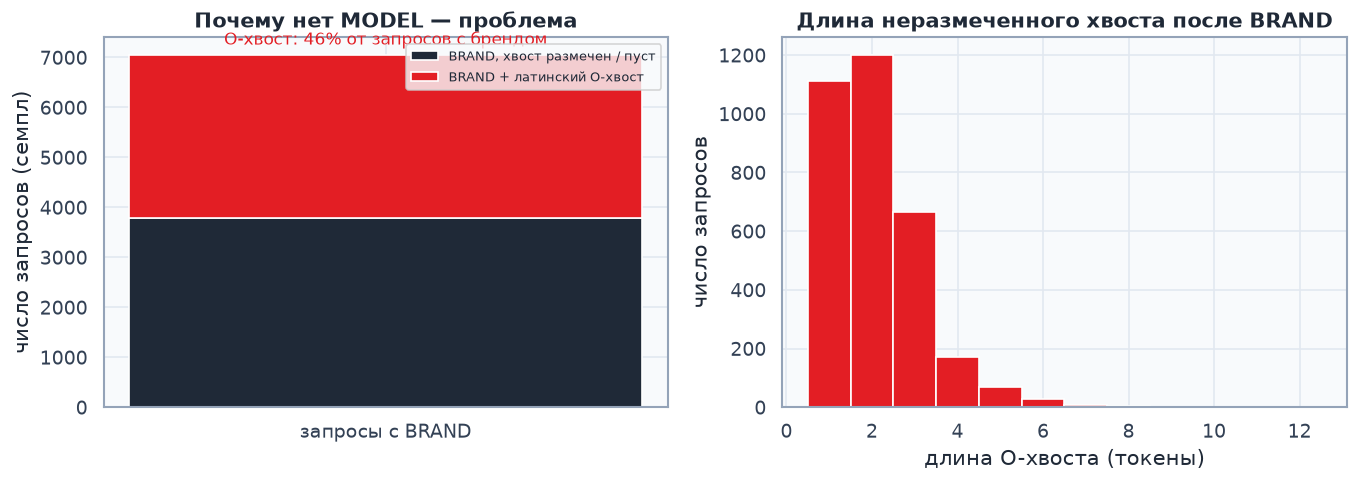

In [4]:
# --- График 1: доля «потерянного» хвоста ---
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2))

# stacked bars: brand queries split into clean vs O-tail
clean = n_with_brand - n_o_tail
axes[0].bar([0], [clean], color=DARK_SLATE, label="BRAND, хвост размечен / пуст")
axes[0].bar([0], [n_o_tail], bottom=[clean], color=MVIDEO_RED, label="BRAND + латинский O-хвост")
axes[0].set_xticks([0])
axes[0].set_xticklabels(["запросы с BRAND"])
axes[0].set_ylabel("число запросов (семпл)")
axes[0].set_title("Почему нет MODEL — проблема")
axes[0].legend(loc="upper right", fontsize=8)
axes[0].text(0, n_with_brand + max(n_with_brand, 1) * 0.03,
             f"O-хвост: {n_o_tail / max(n_with_brand,1):.0%} от запросов с брендом",
             ha="center", fontsize=10, color=MVIDEO_RED)

# length of O-tails
axes[1].hist(tail_lens, bins=range(1, max(tail_lens + [1]) + 2), color=MVIDEO_RED,
             edgecolor="white", align="left")
axes[1].set_xlabel("длина O-хвоста (токены)")
axes[1].set_ylabel("число запросов")
axes[1].set_title("Длина неразмеченного хвоста после BRAND")
fig.tight_layout()
save_local(fig, "01_missing_model_problem.png")
plt.show()


saved D:\Projects-26-06-2026\mvideo-ner-search\figures\complex_eda\model_tag\02_top_lost_tails.png


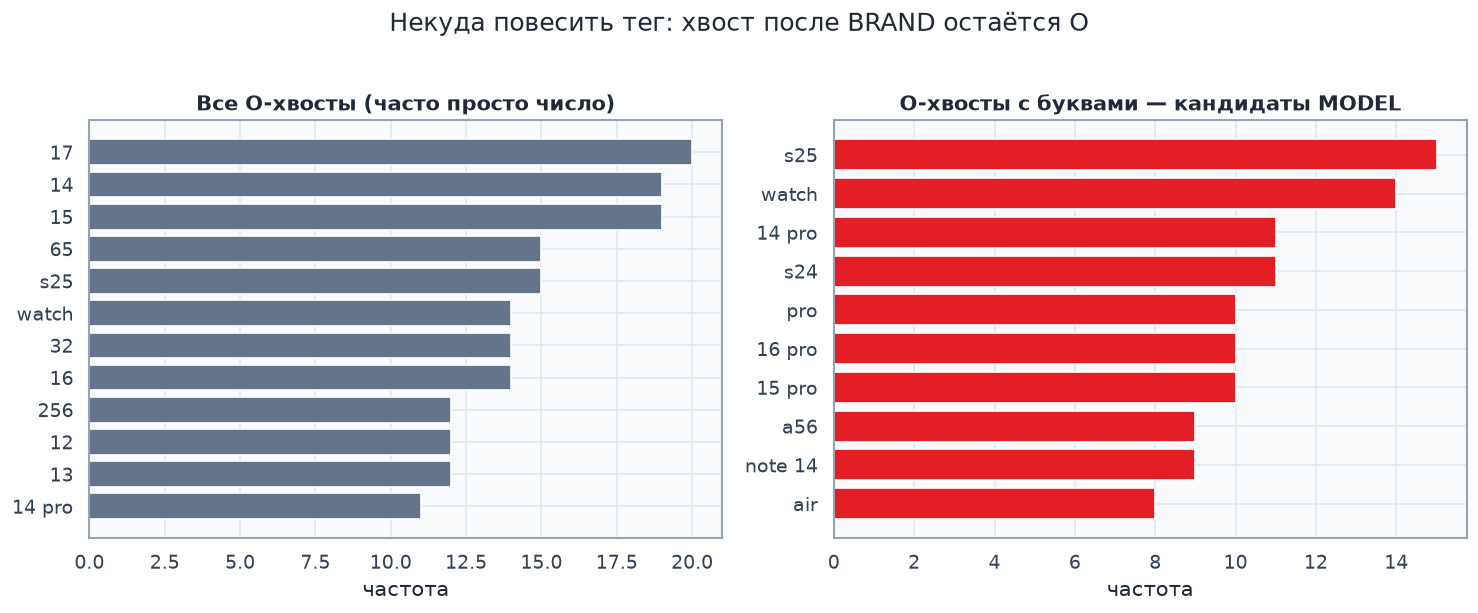

,o_tail_phrase,count
0,s25,15
1,watch,14
2,14 pro,11
3,s24,11
4,pro,10
5,16 pro,10
6,15 pro,10
7,a56,9
8,note 14,9
9,air,8


In [5]:
# --- График 2: топ «потерянных» фраз ---
# Голые числа (15/16/55) — частый O-хвост, но это скорее generation/ATTR, не product-line.
# Для MODEL важнее хвосты с буквами: g pro, watch, air, ...
top_all = pd.DataFrame(tail_phrases.most_common(25), columns=["o_tail_phrase", "count"])
top_modelish = (
    top_all[top_all["o_tail_phrase"].str.contains(r"[A-Za-zА-Яа-я]", regex=True)]
    .head(15)
    .reset_index(drop=True)
)

fig, axes = plt.subplots(1, 2, figsize=(12.5, 5.0))
axes[0].barh(top_all.head(12)["o_tail_phrase"][::-1], top_all.head(12)["count"][::-1], color=MUTED)
axes[0].set_title("Все O-хвосты (часто просто число)")
axes[0].set_xlabel("частота")
axes[1].barh(top_modelish["o_tail_phrase"][::-1], top_modelish["count"][::-1], color=MVIDEO_RED)
axes[1].set_title("O-хвосты с буквами — кандидаты MODEL")
axes[1].set_xlabel("частота")
fig.suptitle("Некуда повесить тег: хвост после BRAND остаётся O", y=1.02)
fig.tight_layout()
save_local(fig, "02_top_lost_tails.png")
plt.show()
display(top_modelish)


## 2. Майнинг `model_phrases` — это парсинг `sku_name`

**Не нейросеть.** Алгоритм:

1. Берём название SKU: `Наушники Logitech G PRO X SE Black`
2. Нормализуем (`g-pro` → `g pro`)
3. Находим токен бренда (`logitech`)
4. Снимаем 1…K следующих коротких `[a-z0-9]+` токенов → фразы `g`, `g pro`, `g pro x`, `g pro x se`
5. Считаем частоту фразы по каталогу/кликам
6. Режем порогами (ниже) → пишем в `model_phrases.txt`

Дополнительно: сиды (`MODEL_SEEDS`) + lead-паттерны `g/v/galaxy/…`.


In [6]:
brands_top = (
    clicks["sku_brand_name"].astype(str).str.strip().replace("", np.nan)
    .dropna().value_counts().head(400).index.tolist()
)
titles = clicks["sku_name"].astype(str).dropna().drop_duplicates().tolist()
print("unique titles:", len(titles))

# сырой майнинг с низким порогом — потом режем сами
raw = build_model_lexicon_from_titles(
    titles, brands_top, min_count=2, max_phrase_tokens=4,
)
raw_df = (
    pd.DataFrame([{"phrase": p, "count": c, "n_tok": len(p.split())} for p, c in raw.items()])
    .sort_values("count", ascending=False)
    .reset_index(drop=True)
)
print("raw candidates:", len(raw_df))
display(raw_df.head(15))


unique titles: 47032
raw candidates: 8540


,phrase,count,n_tok
0,galaxy,1454,1
1,iphone,1231,1
2,watch,490,1
3,redmi,460,1
4,iphone 17,443,2
5,iphone 17 pro max,373,4
6,note,313,1
7,iphone 17 pro,298,3
8,galaxy s25,265,2
9,macbook,228,1


## 3. Пороги: что попадает в `model_phrases.txt`

| Порог | Смысл | Типичный выбор |
|---|---|---|
| `min_count` | сколько раз фраза встретилась в titles | **5–8** (шум↓) |
| `min_tokens` | мин. длина фразы | **2** (кроме кодов `v15`, `g305`) |
| `require_alpha` | есть буква (не чистое число) | **да** |
| `max_tokens` | уже в майнере | 4 |
| сиды | всегда включаем | `MODEL_SEEDS` |

Ниже — кривые: размер словаря и покрытие O-хвостов запросов vs `min_count`.


,min_count,dict_size,o_tail_coverage
0,2,7215,0.354384
1,3,3783,0.317597
2,4,2601,0.280809
3,5,1894,0.243102
4,6,1512,0.220110
5,7,1246,0.204782
6,8,1079,0.193440
7,9,905,0.176885
8,10,802,0.171367
9,11,709,0.159718


saved D:\Projects-26-06-2026\mvideo-ner-search\figures\complex_eda\model_tag\03_threshold_tradeoff.png


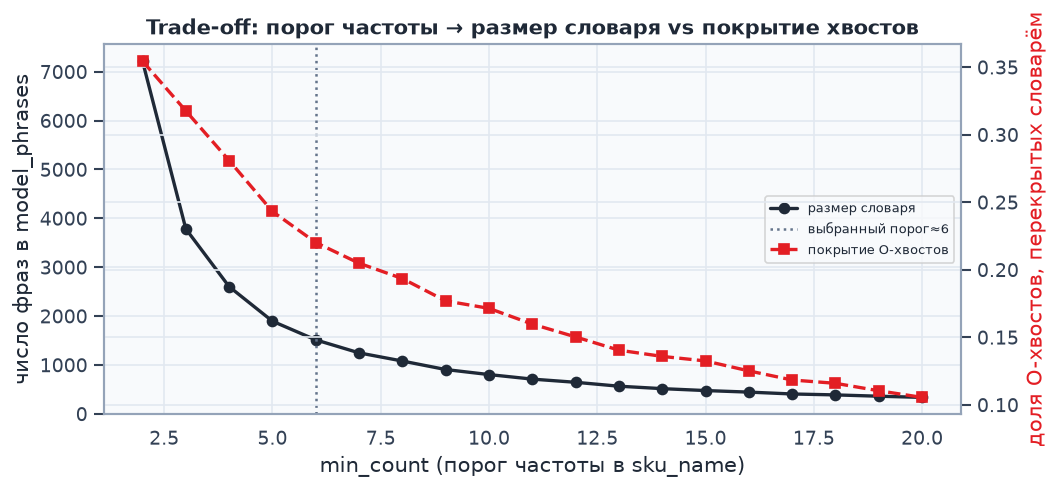

In [7]:
def accept_phrase(phrase: str, count: int, min_count: int, min_tokens: int = 2) -> bool:
    toks = phrase.split()
    if count < min_count and phrase not in MODEL_SEEDS:
        return False
    if phrase in MODEL_SEEDS:
        return True
    if all(t.replace(".", "").isdigit() for t in toks):
        return False
    # однотокенные: только «коды» с буквой+цифрой (v15, g305, m2, ps5)
    if len(toks) == 1:
        t = toks[0]
        return any(c.isalpha() for c in t) and any(c.isdigit() for c in t) and 2 <= len(t) <= 10
    return len(toks) >= min_tokens

# coverage helper: доля O-хвостов, которые lexicon перекрыл бы
def coverage_for_phrases(phrases_set, queries_tags_tails):
    hit = 0
    # longest-first
    plist = sorted(phrases_set, key=lambda s: (-len(s.split()), -len(s)))
    for tail_toks in queries_tags_tails:
        joined = " ".join(tail_toks)
        ok = False
        for p in plist:
            if joined == p or joined.startswith(p + " ") or p in joined:
                # более строго: prefix match по токенам
                pt = p.split()
                if tail_toks[: len(pt)] == pt:
                    ok = True
                    break
        hit += int(ok)
    return hit / max(len(queries_tags_tails), 1)

o_tails_list = []
for q in sample_q:
    qn = QueryPreprocessor()(q).text_norm
    tags = labeler_base.label_query(qn)
    tail = brand_latin_o_tail(tags)
    if tail:
        o_tails_list.append(tail)

thresholds = list(range(2, 21))
rows = []
for mc in thresholds:
    kept = {p for p, c in raw.items() if accept_phrase(p, c, min_count=mc)}
    kept |= set(MODEL_SEEDS)
    cov = coverage_for_phrases(kept, o_tails_list)
    rows.append({"min_count": mc, "dict_size": len(kept), "o_tail_coverage": cov})

thr_df = pd.DataFrame(rows)
display(thr_df)

fig, ax1 = plt.subplots(figsize=(9, 4.2))
ax2 = ax1.twinx()
ax1.plot(thr_df["min_count"], thr_df["dict_size"], "o-", color=DARK_SLATE, lw=2, label="размер словаря")
ax2.plot(thr_df["min_count"], thr_df["o_tail_coverage"], "s--", color=MVIDEO_RED, lw=2, label="покрытие O-хвостов")
ax1.set_xlabel("min_count (порог частоты в sku_name)")
ax1.set_ylabel("число фраз в model_phrases", color=DARK_SLATE)
ax2.set_ylabel("доля O-хвостов, перекрытых словарём", color=MVIDEO_RED)
ax1.set_title("Trade-off: порог частоты → размер словаря vs покрытие хвостов")
ax1.axvline(6, color=MUTED, ls=":", label="выбранный порог≈6")
# combined legend
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc="center right", fontsize=8)
fig.tight_layout()
save_local(fig, "03_threshold_tradeoff.png")
plt.show()


## 4. Финальный словарь и сохранение

Выбираем `min_count = 6` (баланс на кривой; при необходимости поменяйте).  
Сиды всегда входят.


In [8]:
MIN_COUNT = 6
MIN_TOKENS = 2

final = {p for p, c in raw.items() if accept_phrase(p, c, min_count=MIN_COUNT, min_tokens=MIN_TOKENS)}
final |= set(MODEL_SEEDS)
path = save_phrase_list(final, ART / "model_phrases.txt")
print(f"saved {len(final)} phrases → {path}")

# показать пересечение с «потерянными» хвостами
lost_hit = []
final_sorted = sorted(final, key=lambda s: (-len(s.split()), -len(s)))
for phrase, cnt in tail_phrases.most_common(30):
    pt = phrase.split()
    exact = phrase in final
    prefix = any(pt[: len(p.split())] == p.split() for p in final_sorted if len(p.split()) <= len(pt))
    lost_hit.append({
        "o_tail": phrase,
        "query_freq": cnt,
        "exact_in_dict": exact,
        "prefix_in_dict": prefix,
    })
display(pd.DataFrame(lost_hit).head(15))


saved 1512 phrases → D:\Projects-26-06-2026\mvideo-ner-search\artifacts\model_phrases.txt


,o_tail,query_freq,exact_in_dict,prefix_in_dict
0,17,20,False,False
1,14,19,False,False
2,15,19,False,False
3,65,15,False,False
4,s25,15,False,False
5,watch,14,False,False
6,32,14,False,False
7,16,14,False,False
8,256,12,False,False
9,12,12,False,False


## 5. After: `WeakLabeler` с `models_path` → теги `B-MODEL` / `I-MODEL`

В `labeling.py` уже поддержан словарь моделей: `from_files(..., models_path=artifacts/model_phrases.txt)`.


In [9]:
labeler_model = WeakLabeler.from_files(
    ART / "brands.txt",
    ART / "categories.txt",
    models_path=ART / "model_phrases.txt",
)
print("models in labeler:", len(labeler_model.models))

demos = [
    "наушники logitech g-pro x se",
    "пылесос dyson v15",
    "samsung galaxy s24 ultra",
    "ноутбук asus 16 гб",
]
rows = []
for q in demos:
    qn = QueryPreprocessor()(q).text_norm
    before = labeler_base.label_query(qn)
    after = labeler_model.label_query(qn)
    ent = bio_to_entities(after, query=qn)
    struct = entities_to_structured(ent, labeler_model)
    rows.append({
        "query": qn,
        "bio_before": before,
        "bio_after": after,
        "structured": struct,
    })
pd.DataFrame(rows)[["query", "bio_before", "bio_after", "structured"]]


models in labeler: 1512


,query,bio_before,bio_after,structured
0,наушники logitech g pro x se,"[(наушники, B-CATEGORY), (logitech, B-BRAND), ...","[(наушники, B-CATEGORY), (logitech, B-BRAND), ...","{'brand': 'Logitech', 'category': 'наушники', ..."
1,пылесос dyson v15,"[(пылесос, B-CATEGORY), (dyson, B-BRAND), (v15...","[(пылесос, B-CATEGORY), (dyson, B-BRAND), (v15...","{'brand': 'Dyson', 'category': 'пылесос', 'mod..."
2,samsung galaxy s24 ultra,"[(samsung, B-BRAND), (galaxy, B-BRAND), (s24, ...","[(samsung, B-BRAND), (galaxy, B-BRAND), (s24, ...","{'brand': 'Samsung', 'category': None, 'model'..."
3,ноутбук asus 16 гб,"[(ноутбук, B-CATEGORY), (asus, B-BRAND), (16, ...","[(ноутбук, B-CATEGORY), (asus, B-BRAND), (16, ...","{'brand': 'ASUS', 'category': 'ноутбук', 'mode..."


,stage,latin_O_tails,queries_with_MODEL
0,до (нет MODEL),3262,0
1,после (словарь MODEL),2502,1573


saved D:\Projects-26-06-2026\mvideo-ner-search\figures\complex_eda\model_tag\04_before_after_model_tag.png


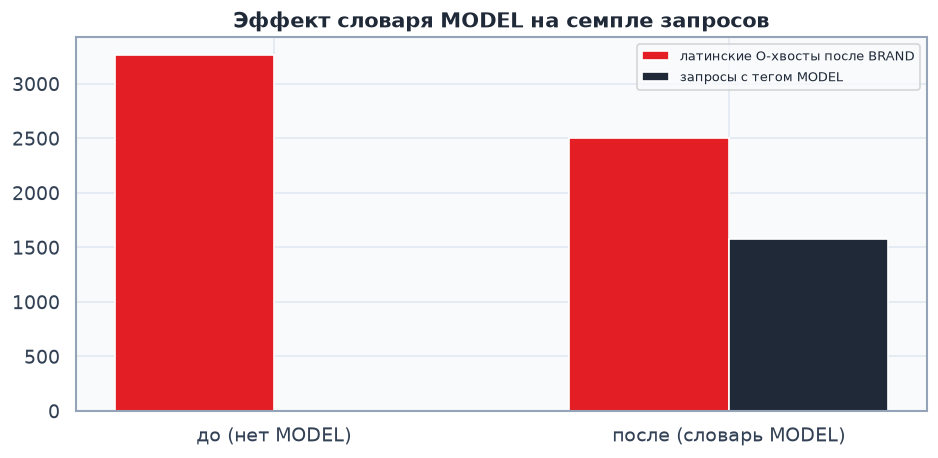

O-хвосты сократились на 23.3%: 3262 → 2502


In [10]:
# --- График 4: до/после — доля запросов с MODEL и остаток O-хвостов ---
n_model_after = 0
n_o_tail_after = 0
for q in sample_q:
    qn = QueryPreprocessor()(q).text_norm
    tags = labeler_model.label_query(qn)
    if any(t.endswith("MODEL") for _, t in tags):
        n_model_after += 1
    if brand_latin_o_tail(tags) is not None:
        n_o_tail_after += 1

cmp = pd.DataFrame([
    {"stage": "до (нет MODEL)", "latin_O_tails": n_o_tail, "queries_with_MODEL": 0},
    {"stage": "после (словарь MODEL)", "latin_O_tails": n_o_tail_after, "queries_with_MODEL": n_model_after},
])
display(cmp)

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(2)
w = 0.35
ax.bar(x - w/2, cmp["latin_O_tails"], w, color=MVIDEO_RED, label="латинские O-хвосты после BRAND")
ax.bar(x + w/2, cmp["queries_with_MODEL"], w, color=DARK_SLATE, label="запросы с тегом MODEL")
ax.set_xticks(x)
ax.set_xticklabels(cmp["stage"])
ax.set_title("Эффект словаря MODEL на семпле запросов")
ax.legend(fontsize=8)
fig.tight_layout()
save_local(fig, "04_before_after_model_tag.png")
plt.show()

reduction = 1 - n_o_tail_after / max(n_o_tail, 1)
print(f"O-хвосты сократились на {reduction:.1%}: {n_o_tail} → {n_o_tail_after}")


## 6. Выводы

1. Без тега MODEL серебряная разметка **врёт**: линейка выглядит как фон (`O`), CRF не на чем учиться.  
2. Майнинг = частотный парсинг хвоста `sku_name` после бренда + сиды.  
3. Порог `min_count≈6` + фильтр «не чистое число» / однотокен только `v15`-like — разумный дефолт (смотрите кривую).  
4. Словарь конечен → оставшиеся O-хвосты = кандидаты в **gold** с ручным `B-MODEL`/`I-MODEL`.  
5. Дальше: переобучить CRF на silver с MODEL (`06`/`08` ноутбуки), используя `models_path`.


In [11]:
out = {
    "sample_queries": len(sample_q),
    "with_brand": n_with_brand,
    "latin_o_tails_before": n_o_tail,
    "latin_o_tails_after": n_o_tail_after,
    "o_tail_reduction": float(reduction),
    "queries_with_model_after": n_model_after,
    "min_count": MIN_COUNT,
    "n_model_phrases": len(final),
    "chosen_threshold_table": thr_df.to_dict(orient="records"),
}
save_stats(out, "model_tag_eda_stats.json")
pd.DataFrame([(k, v) for k, v in out.items() if k != "chosen_threshold_table"], columns=["metric", "value"])


Статистика сохранена: D:\Projects-26-06-2026\mvideo-ner-search\artifacts\model_tag_eda_stats.json


,metric,value
0,sample_queries,15000.000000
1,with_brand,7046.000000
2,latin_o_tails_before,3262.000000
3,latin_o_tails_after,2502.000000
4,o_tail_reduction,0.232986
5,queries_with_model_after,1573.000000
6,min_count,6.000000
7,n_model_phrases,1512.000000
